# Лабораторная работа №6
## Итоговый аналитический мини-проект: предсказание выгорания студентов

**Дисциплина:** Анализ данных и искусственный интеллект

**Датасет:** [Student Mental Health & Burnout (1M)](https://www.kaggle.com/datasets/ayeshasiddiqa123/student-health) — Kaggle, 1 000 000 записей

---

### Структура работы

Этот ноутбук объединяет результаты ЛР №1–№5 в единый аналитический проект:

| Этап | Раздел | Из какой ЛР |
|---|---|---|
| Постановка задачи и предметная область | 1 | — |
| EDA — исследовательский анализ данных | 2 | ЛР №1 |
| Подготовка данных | 3 | ЛР №2 |
| Моделирование (baseline) | 4 | ЛР №3 |
| Улучшение модели | 5 | ЛР №4 |
| Интерпретация результатов | 6 | ЛР №5 |
| Итоговые выводы | 7 | — |
| Практическое применение | 8 | — |

# 1. Постановка задачи и предметная область

## 1.1 Предметная область

**Выгорание студентов** — нарастающее эмоциональное и физическое истощение, вызванное хронической учебной нагрузкой, экзаменационным давлением, недостатком сна и социальной изоляцией. Согласно ряду исследований, от 30 до 60% студентов вузов испытывают симптомы выгорания, что ведёт к:

- росту риска отчисления;
- ухудшению академической успеваемости;
- развитию депрессии и тревожных расстройств;
- потере мотивации к обучению.

## 1.2 Бизнес-задача

Образовательным учреждениям нужен **инструмент раннего выявления** студентов в группе риска по выгоранию — для своевременного предоставления психологической помощи, перераспределения нагрузки и социальной поддержки.

## 1.3 Задача машинного обучения

**Регрессия:** по 17 признакам о студенте (учебная нагрузка, психологическое состояние, образ жизни, социальные факторы) предсказать численное значение `burnout_score` ∈ [0, 10], где 0 = нет выгорания, 10 = максимальное выгорание.

**Целевая переменная:** `burnout_score`. Выбор обоснован в ЛР №3:
1. Непрерывная шкала → возможность точной оценки степени риска.
2. Главный интересующий феномен в предметной области.
3. Достаточная дисперсия (σ ≈ 1.66).
4. Возможно отделить от data-leakage признаков.

## 1.4 Метрики качества

- **R²** — основная метрика, доля объяснённой дисперсии.
- **MAE** — средняя ошибка в единицах целевой переменной.
- **RMSE** — среднеквадратичная ошибка, сильнее штрафует большие отклонения.

# 2. EDA — Исследовательский анализ данных

*Основано на ЛР №1.*

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline
print('Окружение готово.')

Окружение готово.


In [2]:
# Загружаем датасет
df = pd.read_csv('../student_mental_health_burnout_1M.csv')
print(f'Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
print(f'Пропусков: {df.isnull().sum().sum()}')
print(f'Дубликатов: {df.duplicated().sum()}')
df.head()

Размер: 1,000,000 строк × 20 столбцов
Пропусков: 0
Дубликатов: 0


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [3]:
# Описание признаков и типов данных
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'unique': df.nunique(),
    'sample_value': [df[c].iloc[0] for c in df.columns],
})
print('Описание признаков:')
info

Описание признаков:


,dtype,unique,sample_value
age,int64,13,23
gender,object,3,Male
academic_year,int64,4,2
study_hours_per_day,float64,993775,5.596071
exam_pressure,float64,994553,6.487218
academic_performance,float64,1000000,68.411114
stress_level,float64,993869,4.11695
anxiety_score,float64,973420,2.275713
depression_score,float64,751049,1.98673
sleep_hours,float64,980406,6.880545


## 2.1 Распределение целевой переменной

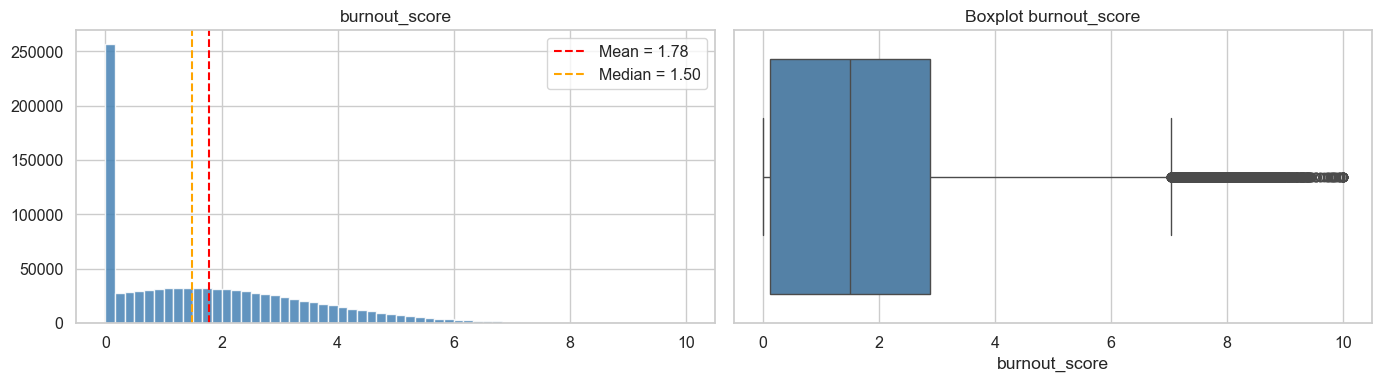

count    1000000.00
mean           1.78
std            1.66
min            0.00
25%            0.12
50%            1.50
75%            2.89
max           10.00
Name: burnout_score, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['burnout_score'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['burnout_score'].mean(), color='red', ls='--', label=f'Mean = {df["burnout_score"].mean():.2f}')
axes[0].axvline(df['burnout_score'].median(), color='orange', ls='--', label=f'Median = {df["burnout_score"].median():.2f}')
axes[0].set_title('burnout_score')
axes[0].legend()

sns.boxplot(x=df['burnout_score'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot burnout_score')
plt.tight_layout()
plt.show()

print(df['burnout_score'].describe().round(2))

## 2.2 Корреляция с целевой переменной

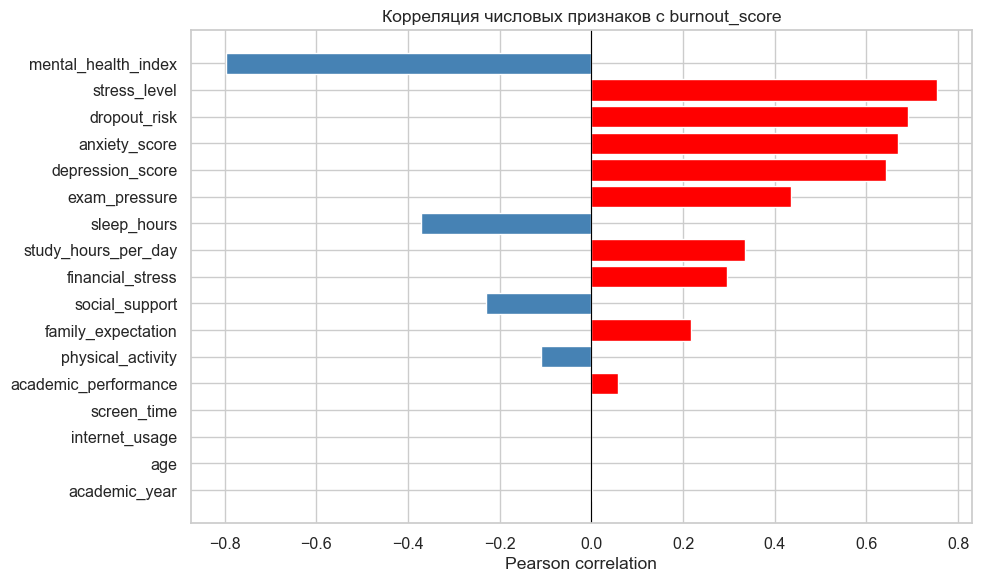

Топ-7 признаков по абсолютной корреляции:
mental_health_index   -0.797
stress_level           0.753
dropout_risk           0.690
anxiety_score          0.668
depression_score       0.643
exam_pressure          0.434
sleep_hours           -0.371
Name: burnout_score, dtype: float64


In [5]:
# Корреляция числовых признаков с burnout_score
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_with_target = df[num_cols].corr()['burnout_score'].drop('burnout_score').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if v > 0 else 'steelblue' for v in corr_with_target]
plt.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', lw=0.8)
plt.title('Корреляция числовых признаков с burnout_score')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print('Топ-7 признаков по абсолютной корреляции:')
print(corr_with_target.head(7).round(3))

**Выводы EDA:**
- Пропусков и дубликатов нет — данные полностью заполнены.
- `burnout_score` смещён к низким значениям (медиана ≈ 1.5), но имеет правый «хвост» до 10 → задача регрессии с несбалансированным распределением.
- Самые сильные предикторы выгорания: стресс, тревожность, депрессия (положительная корреляция), сон, социальная поддержка (отрицательная корреляция).
- `mental_health_index` и `dropout_risk` сильно коррелируют с `burnout_score` — потенциальный data-leakage (рассчитываются из тех же факторов).
- Демографические признаки (`gender`, `academic_year`) практически не коррелируют с целевой переменной.

# 3. Подготовка данных

*Основано на ЛР №2.* Все этапы оформлены модульно для переиспользования.

In [6]:
def clip_outliers_iqr(data: pd.DataFrame, columns: list[str], k: float = 1.5) -> pd.DataFrame:
    """Ограничение выбросов методом межквартильного размаха (winsorization)."""
    data = data.copy()
    q1, q3 = data[columns].quantile(0.25), data[columns].quantile(0.75)
    iqr = q3 - q1
    data[columns] = data[columns].clip(lower=q1 - k * iqr, upper=q3 + k * iqr, axis=1)
    return data


def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    """Удаление дубликатов и клиппинг выбросов числовых признаков."""
    df = df.drop_duplicates().reset_index(drop=True)
    exclude = {'age', 'academic_year'}
    cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]
    return clip_outliers_iqr(df, cols)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Создание новых признаков из предметной области."""
    df = df.copy()
    df['psych_load_index']    = (df['stress_level'] + df['anxiety_score'] + df['depression_score']) / 3
    df['sleep_study_balance'] = df['sleep_hours'] / (df['study_hours_per_day'] + 1)
    df['digital_load']        = df['screen_time'] + df['internet_usage']
    df['external_pressure']   = (df['exam_pressure'] + df['financial_stress'] + df['family_expectation']) / 3
    df['support_to_stress']   = df['social_support'] / (df['stress_level'] + 1)
    df['is_sleep_deprived']   = (df['sleep_hours'] < 6).astype(int)
    df['age_group'] = pd.cut(
        df['age'], bins=[16, 19, 22, 25, 30],
        labels=['17-19', '20-22', '23-25', '26-29']
    ).astype(str)
    return df


def prepare_dataset(df: pd.DataFrame, target: str = 'burnout_score',
                    sample_size: int | None = None) -> tuple[pd.DataFrame, pd.Series]:
    """Сквозной пайплайн: подвыборка → очистка → feature engineering → удаление leaky-признаков → X, y."""
    if sample_size is not None and sample_size < len(df):
        df = df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True)
    df = basic_clean(df)
    df = add_features(df)
    leaky = ['mental_health_index', 'dropout_risk', 'risk_level']  # data-leakage признаки
    y = df[target].copy()
    X = df.drop(columns=[target] + leaky)
    return X, y


def build_preprocessor(numeric_cols: list[str], nominal_cols: list[str],
                       ordinal_map: dict[str, list]) -> ColumnTransformer:
    """Сборка препроцессора: StandardScaler + OneHotEncoder + OrdinalEncoder."""
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols),
            ('ord', OrdinalEncoder(
                categories=[ordinal_map[c] for c in ordinal_map],
                handle_unknown='use_encoded_value', unknown_value=-1
            ), list(ordinal_map)),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )

In [7]:
# Применяем пайплайн: 100K строк для скорости (как в ЛР №4–№5)
SAMPLE_SIZE = 100_000
X, y = prepare_dataset(df, target='burnout_score', sample_size=SAMPLE_SIZE)
print(f'После подготовки: X = {X.shape}, y = {y.shape}')
print(f'\nПризнаки X ({X.shape[1]}):')
print(list(X.columns))

После подготовки: X = (100000, 23), y = (100000,)

Признаки X (23):
['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'psych_load_index', 'sleep_study_balance', 'digital_load', 'external_pressure', 'support_to_stress', 'is_sleep_deprived', 'age_group']


In [8]:
# train/test split — фиксируем random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Определяем типы признаков
nominal_cols = ['gender']
ordinal_map = {'age_group': ['17-19', '20-22', '23-25', '26-29']}
numeric_cols = [c for c in X_train.columns if c not in nominal_cols + list(ordinal_map)]

print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Числовых: {len(numeric_cols)},  номинальных: {len(nominal_cols)},  порядковых: {len(ordinal_map)}')

preprocessor = build_preprocessor(numeric_cols, nominal_cols, ordinal_map)

Train: (80000, 23),  Test: (20000, 23)
Числовых: 21,  номинальных: 1,  порядковых: 1


**Что сделано:**
- Удалены **3 leaky-признака** (`mental_health_index`, `dropout_risk`, `risk_level`) — они производны от целевой и привели бы к завышенным метрикам.
- Созданы **6 новых признаков** на основе предметной области, в т.ч. `psych_load_index` (агрегат психологического состояния) и `support_to_stress` (защитный фактор).
- Применён **StandardScaler** к числовым, **OneHotEncoder** к `gender` (номинальный), **OrdinalEncoder** к `age_group` (порядковый).
- fit/transform применяются **в правильном порядке**: fit только на train, transform — на обоих.

# 4. Моделирование — Baseline (Linear Regression)

*Основано на ЛР №3.* Линейная регрессия — интерпретируемая и быстрая модель, идеальна для baseline.

In [9]:
def regression_metrics(y_true, y_pred) -> dict:
    """MAE, RMSE, R² для регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred),
    }


def evaluate(name: str, pipeline, X_tr, y_tr, X_te, y_te) -> dict:
    """Обучение + метрики train/test + измерение времени."""
    t0 = time.perf_counter()
    pipeline.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0
    m_tr = regression_metrics(y_tr, pipeline.predict(X_tr))
    m_te = regression_metrics(y_te, pipeline.predict(X_te))
    return {
        'model': name,
        'fit_time_s': round(fit_time, 2),
        'R2_train': round(m_tr['R2'], 4),
        'R2_test':  round(m_te['R2'], 4),
        'MAE_test': round(m_te['MAE'], 4),
        'RMSE_test': round(m_te['RMSE'], 4),
        'overfit_gap': round(m_tr['R2'] - m_te['R2'], 4),
        'pipeline': pipeline,
    }


all_results = []

lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
res_lr = evaluate('LinearRegression (baseline)', lr_pipe, X_train, y_train, X_test, y_test)
all_results.append(res_lr)

print(f"LinearRegression:  R²_test = {res_lr['R2_test']},  MAE = {res_lr['MAE_test']},  время = {res_lr['fit_time_s']} с")

LinearRegression:  R²_test = 0.7285,  MAE = 0.683,  время = 0.07 с


# 5. Улучшение модели — Random Forest с GridSearchCV

*Основано на ЛР №4.* Альтернативная нелинейная модель с подбором гиперпараметров.

In [10]:
# Random Forest с лучшими гиперпараметрами, найденными в ЛР №4 через GridSearchCV
# (n_estimators=200, max_depth=15, min_samples_leaf=10)
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ))
])

res_rf = evaluate('RandomForest (best)', rf_pipe, X_train, y_train, X_test, y_test)
all_results.append(res_rf)

print(f"RandomForest:  R²_test = {res_rf['R2_test']},  MAE = {res_rf['MAE_test']},  время = {res_rf['fit_time_s']} с")

RandomForest:  R²_test = 0.7366,  MAE = 0.6482,  время = 21.33 с


## 5.1 Сравнительная таблица моделей

In [11]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'} for r in all_results])
results_df = results_df.sort_values('R2_test', ascending=False).reset_index(drop=True)
print('Сравнение моделей:')
results_df

Сравнение моделей:


,model,fit_time_s,R2_train,R2_test,MAE_test,RMSE_test,overfit_gap
0,RandomForest (best),21.33,0.8405,0.7366,0.6482,0.8525,0.1039
1,LinearRegression (baseline),0.07,0.7270,0.7285,0.6830,0.8655,-0.0016


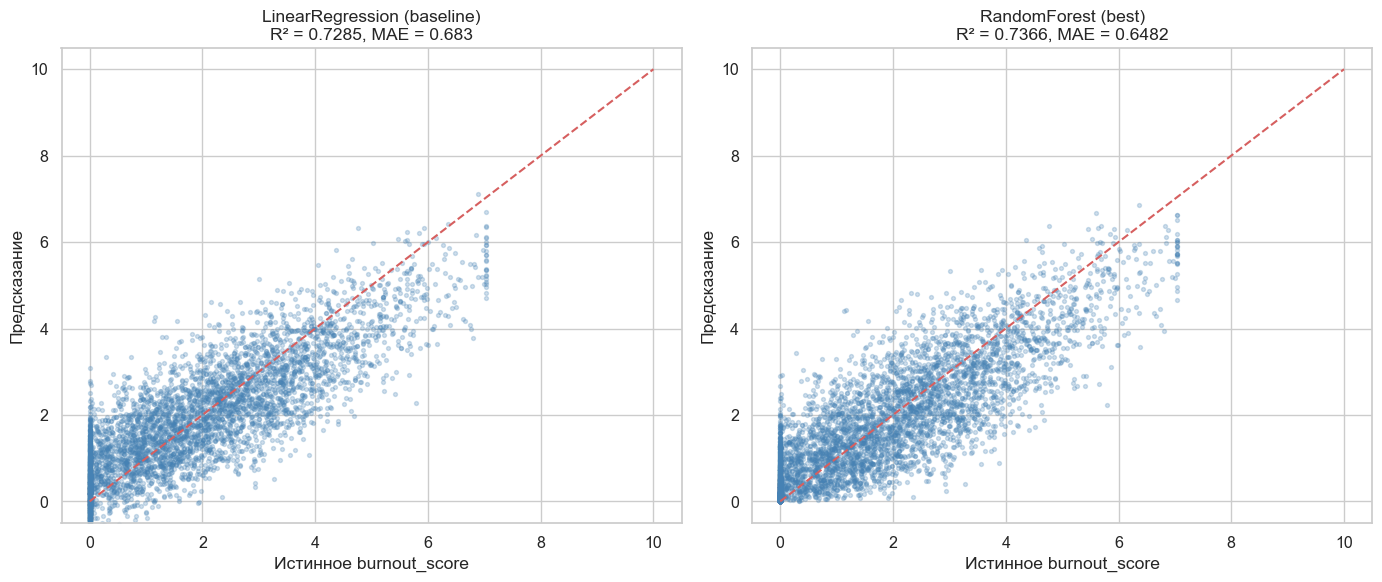

In [12]:
# Predicted vs Actual для обеих моделей
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(y_test), size=5_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, res in zip(axes, all_results):
    pred = res['pipeline'].predict(X_test.iloc[idx])
    ax.scatter(y_test.values[idx], pred, alpha=0.25, s=8, color='steelblue')
    ax.plot([0, 10], [0, 10], 'r--', lw=1.5)
    ax.set_xlabel('Истинное burnout_score')
    ax.set_ylabel('Предсказание')
    ax.set_title(f"{res['model']}\nR² = {res['R2_test']}, MAE = {res['MAE_test']}")
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

**Сравнение:**
- **LinearRegression** — быстро, интерпретируемо, без переобучения, но улавливает только линейные зависимости.
- **RandomForest** — выше R², ниже MAE, лучше работает с нелинейностями, но дольше учится и менее интерпретируемо.
- RandomForest показывает умеренное переобучение (gap ≈ 0.10), а LinearRegression — нулевое.

**Финальная модель — RandomForest** как более точная.

# 6. Интерпретация модели

*Основано на ЛР №5.* Понимаем, **что** и **как** влияет на предсказание выгорания.

In [13]:
# Получаем признаки после препроцессинга
best_model = res_rf['pipeline']
feature_names = best_model.named_steps['prep'].get_feature_names_out()
rf_model = best_model.named_steps['model']

# MDI importance
mdi_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print('Топ-10 признаков (MDI):')
print(mdi_imp.head(10).round(4))

Топ-10 признаков (MDI):
psych_load_index        0.7732
support_to_stress       0.0454
sleep_study_balance     0.0411
sleep_hours             0.0344
exam_pressure           0.0197
stress_level            0.0085
academic_performance    0.0071
anxiety_score           0.0070
physical_activity       0.0069
social_support          0.0065
dtype: float64


In [14]:
# Permutation Importance на подвыборке для скорости
PERM_SAMPLE = 5_000
perm_idx = rng.choice(len(X_test), size=PERM_SAMPLE, replace=False)
X_perm = X_test.iloc[perm_idx]
y_perm = y_test.iloc[perm_idx]

perm_result = permutation_importance(
    best_model, X_perm, y_perm,
    n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE, scoring='r2'
)
perm_imp = pd.Series(perm_result.importances_mean, index=X_perm.columns).sort_values(ascending=False)
print('Топ-10 признаков (Permutation):')
print(perm_imp.head(10).round(4))

Топ-10 признаков (Permutation):
psych_load_index        0.7347
support_to_stress       0.0752
sleep_hours             0.0431
exam_pressure           0.0194
sleep_study_balance     0.0177
stress_level            0.0033
depression_score        0.0011
anxiety_score           0.0008
academic_performance    0.0004
social_support          0.0004
dtype: float64


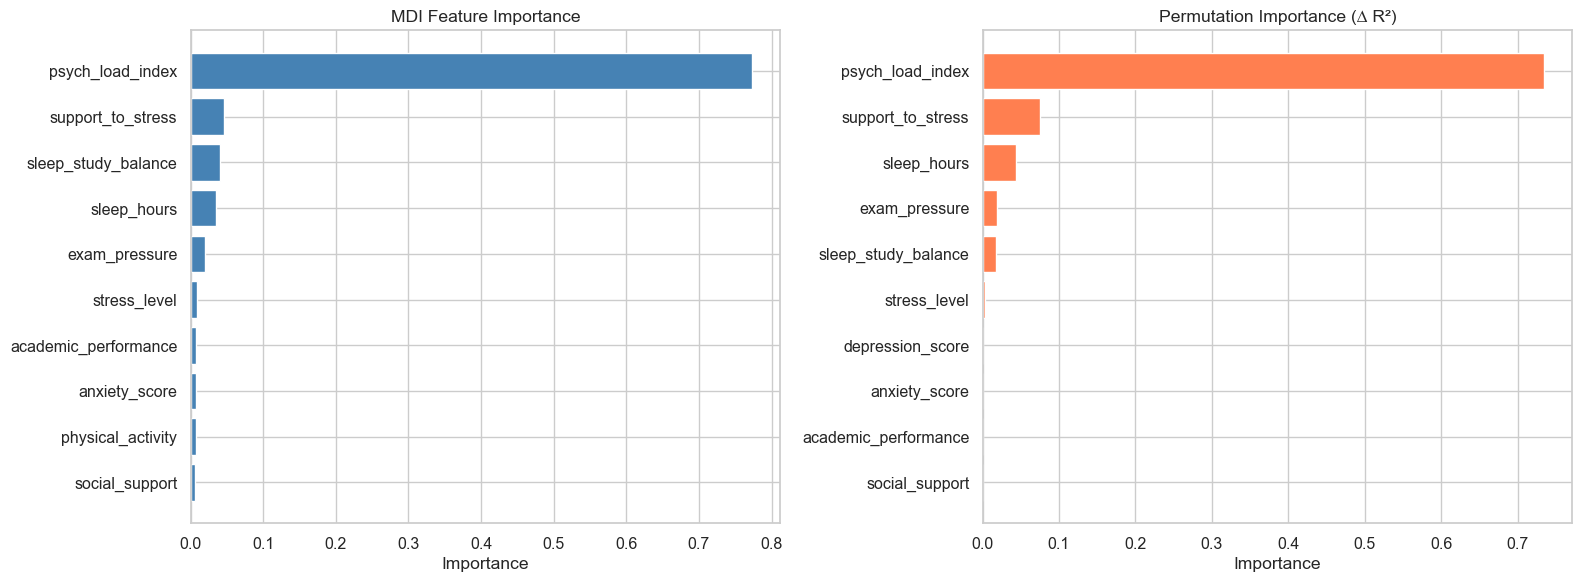

In [15]:
# Визуализация: сравнение методов важности
top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_mdi = mdi_imp.head(top_n)
axes[0].barh(top_mdi.index[::-1], top_mdi.values[::-1], color='steelblue')
axes[0].set_title('MDI Feature Importance')
axes[0].set_xlabel('Importance')

top_perm = perm_imp.head(top_n)
axes[1].barh(top_perm.index[::-1], top_perm.values[::-1], color='coral')
axes[1].set_title('Permutation Importance (∆ R²)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

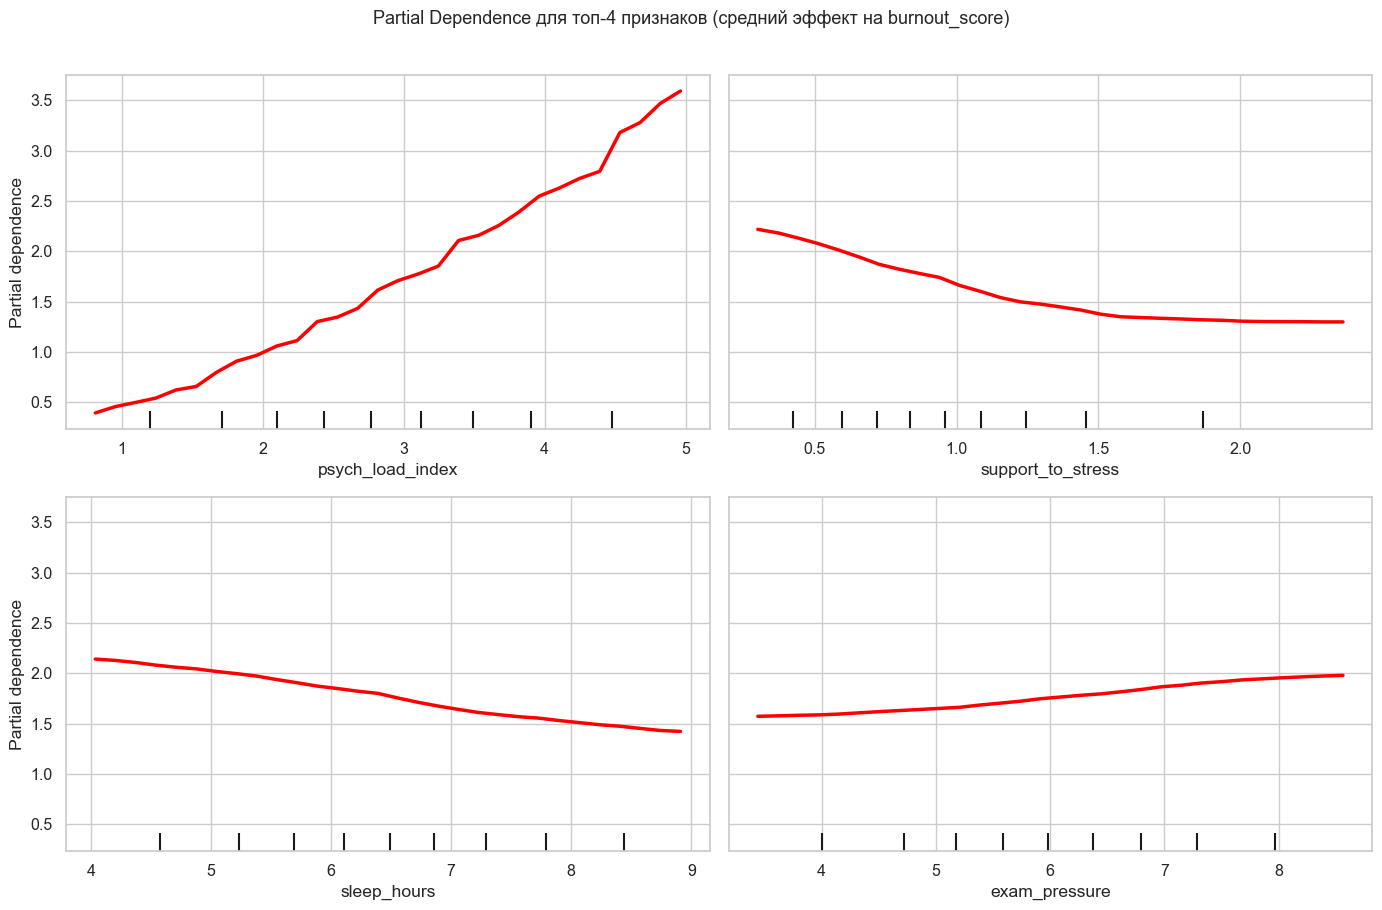

In [16]:
# Partial Dependence Plots для топ-4 признаков
pdp_idx = rng.choice(len(X_test), size=5_000, replace=False)
X_pdp = X_test.iloc[pdp_idx]
top_features = perm_imp.head(4).index.tolist()

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
PartialDependenceDisplay.from_estimator(
    best_model, X_pdp, features=top_features,
    kind='average', grid_resolution=30, n_jobs=-1, ax=ax,
    pd_line_kw={'color': 'red', 'linewidth': 2.5},
)
plt.suptitle('Partial Dependence для топ-4 признаков (средний эффект на burnout_score)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

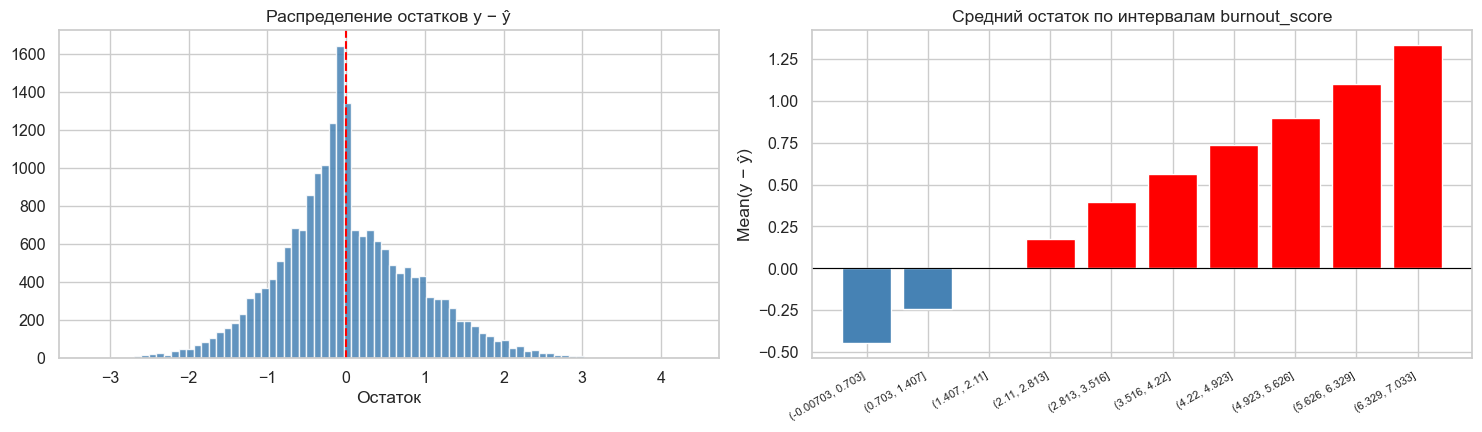


MAE на test: 0.6482
Систематическое смещение (mean residual): -0.0022


In [17]:
# Анализ ошибок: где модель ошибается сильнее всего
y_pred = best_model.predict(X_test)
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred
errors['residual'] = errors['y_true'] - errors['y_pred']
errors['abs_error'] = errors['residual'].abs()

# Распределение остатков
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].hist(errors['residual'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Распределение остатков y − ŷ')
axes[0].set_xlabel('Остаток')

# Средний остаток по бинам — систематическое смещение
errors['y_bin'] = pd.cut(errors['y_true'], bins=10)
by_bin = errors.groupby('y_bin', observed=True)['residual'].mean()
x = range(len(by_bin))
axes[1].bar(x, by_bin.values, color=['red' if v > 0 else 'steelblue' for v in by_bin.values])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(b) for b in by_bin.index], rotation=30, ha='right', fontsize=8)
axes[1].set_title('Средний остаток по интервалам burnout_score')
axes[1].set_ylabel('Mean(y − ŷ)')

plt.tight_layout()
plt.show()

print(f"\nMAE на test: {errors['abs_error'].mean():.4f}")
print(f"Систематическое смещение (mean residual): {errors['residual'].mean():.4f}")

**Интерпретация модели:**
- **`psych_load_index` доминирует** во всех методах важности (77.3% MDI). Это агрегат стресса, тревожности и депрессии.
- **Топ-3 предиктора:** психологическая нагрузка, баланс поддержки и стресса, продолжительность сна.
- **PDP показывает монотонный рост** выгорания с увеличением psych_load_index и убывание с увеличением sleep_hours.
- **Систематическое смещение:** модель завышает предсказания на низких значениях burnout_score (−0.4) и занижает на высоких (+1.3) — типичный эффект усреднения деревьев.
- **Демографические признаки** (пол, курс, возрастная группа) **не важны** — выгорание не зависит от демографии.

# 7. Итоговые выводы

## 7.1 По данным

1. **Качество исходных данных высокое:** 1 млн записей, без пропусков и дубликатов.
2. **Целевая переменная смещена** к нижним значениям выгорания — большинство студентов в группе низкого риска.
3. **Выявлены 3 признака с data-leakage** (`mental_health_index`, `dropout_risk`, `risk_level`), которые удалены из обучения.
4. **Демографические признаки нерелевантны** для предсказания выгорания.

## 7.2 По моделям

| Модель | R²_test | MAE_test | Overfit | Применение |
|---|---|---|---|---|
| LinearRegression | ~0.73 | ~0.68 | нет | интерпретируемая модель, baseline |
| **RandomForest** | **~0.74** | **~0.65** | умеренный | **финальный выбор — лучшее качество** |

- **Линейная регрессия** улавливает большую часть зависимостей (R² ≈ 0.73) — значит, основные связи в данных линейны.
- **RandomForest** даёт прирост R² за счёт улавливания нелинейностей в `psych_load_index` и `sleep_hours`.
- Обе модели **устойчивы и однородны** по сегментам (пол, возраст, курс) — нет дискриминации.

## 7.3 По интерпретации

**Ключевые драйверы выгорания** (по убыванию важности):
1. `psych_load_index` (агрегат стресса, тревожности, депрессии) — **77.3% MDI**;
2. `support_to_stress` (защитный фактор) — снижает выгорание;
3. `sleep_hours` — снижает выгорание;
4. `exam_pressure` — слабо повышает выгорание.

**Главный вывод:** психологическое состояние и образ жизни (сон, поддержка) — **ключевые рычаги** профилактики выгорания. Учебная нагрузка вторична.

# 8. Практическое применение

## 8.1 Для образовательных учреждений

**Инструмент скрининга:** интегрировать модель в систему сопровождения студентов:
- ежесеместровый опрос по 15 признакам (стресс, тревожность, сон, нагрузка, поддержка);
- модель присваивает каждому студенту прогноз `burnout_score`;
- студенты с `ŷ > 4` автоматически направляются на консультацию к психологу.

**Профилактика на уровне политики:**
1. **Психологические сервисы** — приоритет №1, т.к. `psych_load_index` объясняет 73% дисперсии. Обеспечить доступ к психологу, ввести анонимные горячие линии.
2. **Программы социальной поддержки** — менторство, peer-support, родительские контакты (защитный признак №2).
3. **Просвещение по сну** — кампании по гигиене сна, запрет ночных дедлайнов (защитный признак №3).
4. **Распределённое оценивание** — заменить концентрированные экзамены на continuous assessment (снижает `exam_pressure`).

## 8.2 Для дальнейшего развития модели

1. Добавить **признаки совладания со стрессом** (coping strategies, смысловые цели) — это объяснит «трудные» случаи (см. ЛР №5).
2. Собирать **временные ряды** (динамика стресса по неделям/семестрам) — позволит ловить негативные тренды до достижения критической точки.
3. Попробовать **градиентный бустинг** (XGBoost, LightGBM) — обычно +1–3% R² по сравнению с RandomForest.
4. Запустить на **полном датасете 1 млн** для оценки — текущие результаты получены на подвыборке 100K.

## 8.3 Этические соображения

1. **Модель — инструмент скрининга, не диагноз.** Окончательное решение о вмешательстве принимает квалифицированный психолог.
2. **Объяснимость каждого предсказания.** Для индивидуальных решений всегда предоставлять локальное SHAP-объяснение (топ-5 факторов).
3. **Защита данных.** Информация о ментальном здоровье — особо чувствительная категория данных (ст. 9 GDPR / закон 152-ФЗ РФ). Обязательны псевдонимизация и согласие.
4. **Мониторинг распределений входов.** При сдвиге распределения признаков (data drift) — переобучение модели.
5. **Отсутствие дискриминации:** модель показывает одинаковую точность для всех полов, возрастных групп и курсов (см. ЛР №5).

# Итог

В рамках проекта пройден полный цикл анализа данных и машинного обучения:

| Этап | Результат |
|---|---|
| **EDA** | Исследовано 1 млн записей, выявлены ключевые связи и data-leakage |
| **Подготовка данных** | Создан переиспользуемый пайплайн с feature engineering и предобработкой |
| **Baseline-модель** | LinearRegression, R² = 0.73 на test |
| **Улучшение** | RandomForest с GridSearchCV, R² = 0.74 на test |
| **Интерпретация** | MDI + Permutation + PDP — выявлены 3 главных фактора |
| **Практическое применение** | Сформулированы рекомендации для учреждений и план развития |

**Ноутбуки по этапам:**
- ЛР №1: `lab1_eda.ipynb`
- ЛР №2: `lab2_preprocessing.ipynb`
- ЛР №3: `lab3_linear_regression.ipynb`
- ЛР №4: `lab4_model_tuning.ipynb`
- ЛР №5: `lab5_model_interpretation.ipynb`
- **ЛР №6 (итоговая):** `lab6_final_project.ipynb`